<a href="https://colab.research.google.com/github/sathvikteja/MachineLearningAlgorithms/blob/main/Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regression

In [ ]:
from google.colab import files
uploaded=files.upload()


Saving advertising.csv to advertising.csv


In [ ]:
import os
os.listdir()

['.config', 'advertising.csv', 'sample_data']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('advertising.csv')

Plotting the data

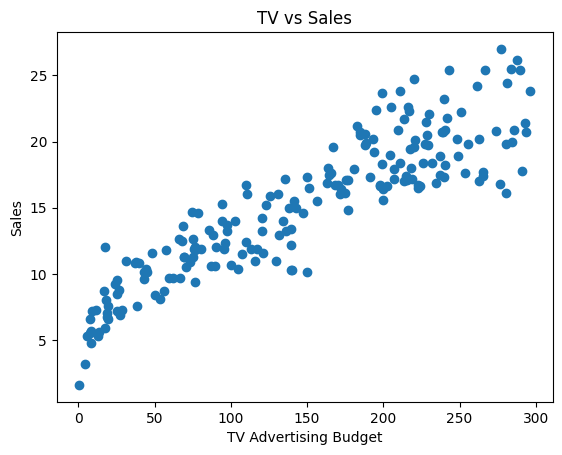

In [ ]:
df.head()
plt.scatter(df['TV'], df['Sales'])
plt.xlabel('TV Advertising Budget')
plt.ylabel('Sales')
plt.title('TV vs Sales')
plt.show()


fitting the regression line

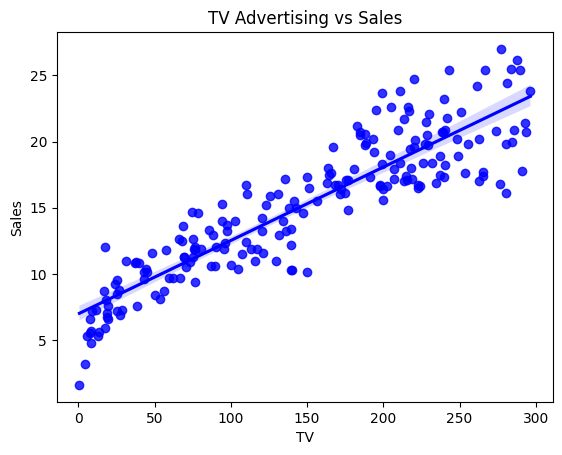

In [ ]:
sns.regplot(x='TV', y='Sales', data=df, color='blue')
plt.title('TV Advertising vs Sales')
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
print(df.shape)

(200, 4)


In [ ]:
X=df.iloc[:,:3].values
y=df.iloc[:,3].values

Splitting data into train and test

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

In [ ]:
print(df.shape)
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(200, 4)
(120, 3)
(40, 3)
(40, 3)


checking for null values

In [ ]:
print(df.isnull().sum())


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

# Add bias column to features
X_train_bias = np.hstack([X_train_scaled, np.ones((X_train_scaled.shape[0],1))])
X_val_bias = np.hstack([X_val_scaled, np.ones((X_val_scaled.shape[0],1))])
X_test_bias = np.hstack([X_test_scaled, np.ones((X_test_scaled.shape[0],1))])

# Closed-form solution
def closed_form_ols(X, y):
    XtX = X.T @ X
    try:
        w = np.linalg.solve(XtX, X.T @ y)
    except np.linalg.LinAlgError:
        w = np.linalg.pinv(XtX) @ X.T @ y
    return w

# Train model
w_ols = closed_form_ols(X_train_bias, y_train)

# Predictions
y_val_pred = X_val_bias @ w_ols
y_test_pred = X_test_bias @ w_ols

# Evaluation
val_mse = mean_squared_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("OLS Validation MSE:", val_mse, "R2:", val_r2)
print("OLS Test MSE:", test_mse, "R2:", test_r2)


OLS Validation MSE: 3.0966066859870605 R2: 0.8371158058180077
OLS Test MSE: 2.859529289648787 R2: 0.9074618932773012


Tring polynomial regression with different degrees

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

degree = 2

# Create polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Add bias column
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0],1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0],1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0],1))])

# Train OLS on polynomial features
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# Predictions
y_val_pred_poly = X_val_poly_bias @ w_poly
y_test_pred_poly = X_test_poly_bias @ w_poly

# Evaluation
val_mse_poly = mean_squared_error(y_val, y_val_pred_poly)
val_r2_poly = r2_score(y_val, y_val_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly)
test_r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial Regression (degree={degree}) Validation MSE: {val_mse_poly:.2f}, R2: {val_r2_poly:.2f}")
print(f"Polynomial Regression (degree={degree}) Test MSE: {test_mse_poly:.2f}, R2: {test_r2_poly:.2f}")


Polynomial Regression (degree=2) Validation MSE: 2.30, R2: 0.88
Polynomial Regression (degree=2) Test MSE: 1.61, R2: 0.95


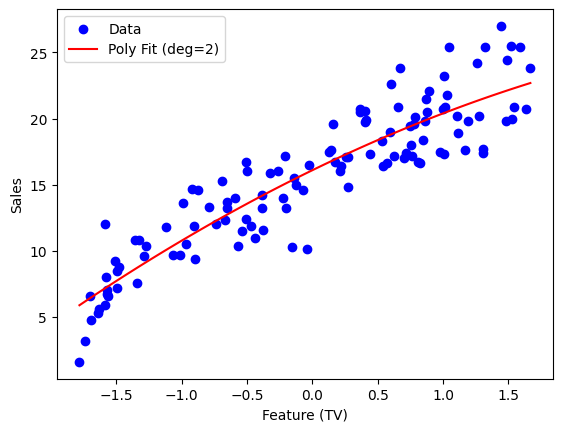

In [ ]:
# Use only one feature (e.g. TV)
X_train_single = X_train_scaled[:, [0]]  # keep as 2D
X_val_single = X_val_scaled[:, [0]]
X_test_single = X_test_scaled[:, [0]]

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_single)
X_val_poly = poly.transform(X_val_single)
X_test_poly = poly.transform(X_test_single)

# Add bias
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0], 1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0], 1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0], 1))])

# Train OLS
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# For curve plotting
X_plot = np.linspace(X_train_single.min(), X_train_single.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
X_plot_poly_bias = np.hstack([X_plot_poly, np.ones((X_plot_poly.shape[0], 1))])
y_plot = X_plot_poly_bias @ w_poly

# Plot
plt.scatter(X_train_single, y_train, color='blue', label='Data')
plt.plot(X_plot, y_plot, color='red', label=f'Poly Fit (deg={degree})')
plt.xlabel('Feature (TV)')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Choose polynomial degree
degree = 3

# Create polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Add bias column
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0],1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0],1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0],1))])

# Train OLS on polynomial features
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# Predictions
y_val_pred_poly = X_val_poly_bias @ w_poly
y_test_pred_poly = X_test_poly_bias @ w_poly

# Evaluation
val_mse_poly = mean_squared_error(y_val, y_val_pred_poly)
val_r2_poly = r2_score(y_val, y_val_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly)
test_r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial Regression (degree={degree}) Validation MSE: {val_mse_poly:.2f}, R2: {val_r2_poly:.2f}")
print(f"Polynomial Regression (degree={degree}) Test MSE: {test_mse_poly:.2f}, R2: {test_r2_poly:.2f}")


Polynomial Regression (degree=3) Validation MSE: 3.54, R2: 0.81
Polynomial Regression (degree=3) Test MSE: 3.23, R2: 0.90


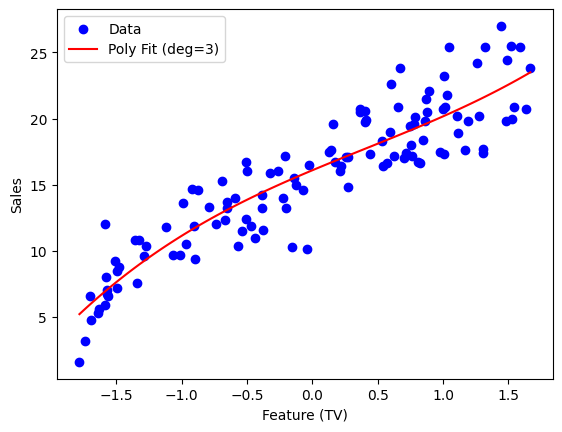

In [ ]:

X_train_single = X_train_scaled[:, [0]]
X_val_single = X_val_scaled[:, [0]]
X_test_single = X_test_scaled[:, [0]]

degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_single)
X_val_poly = poly.transform(X_val_single)
X_test_poly = poly.transform(X_test_single)

# Add bias
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0], 1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0], 1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0], 1))])

# Train OLS
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# For curve plotting
X_plot = np.linspace(X_train_single.min(), X_train_single.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
X_plot_poly_bias = np.hstack([X_plot_poly, np.ones((X_plot_poly.shape[0], 1))])
y_plot = X_plot_poly_bias @ w_poly

# Plot
plt.scatter(X_train_single, y_train, color='blue', label='Data')
plt.plot(X_plot, y_plot, color='red', label=f'Poly Fit (deg={degree})')
plt.xlabel('Feature (TV)')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
degree = 4

# Create polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Add bias column
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0],1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0],1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0],1))])

# Train OLS on polynomial features
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# Predictions
y_val_pred_poly = X_val_poly_bias @ w_poly
y_test_pred_poly = X_test_poly_bias @ w_poly

# Evaluation
val_mse_poly = mean_squared_error(y_val, y_val_pred_poly)
val_r2_poly = r2_score(y_val, y_val_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly)
test_r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial Regression (degree={degree}) Validation MSE: {val_mse_poly:.2f}, R2: {val_r2_poly:.2f}")
print(f"Polynomial Regression (degree={degree}) Test MSE: {test_mse_poly:.2f}, R2: {test_r2_poly:.2f}")


Polynomial Regression (degree=4) Validation MSE: 3.11, R2: 0.84
Polynomial Regression (degree=4) Test MSE: 9.30, R2: 0.70


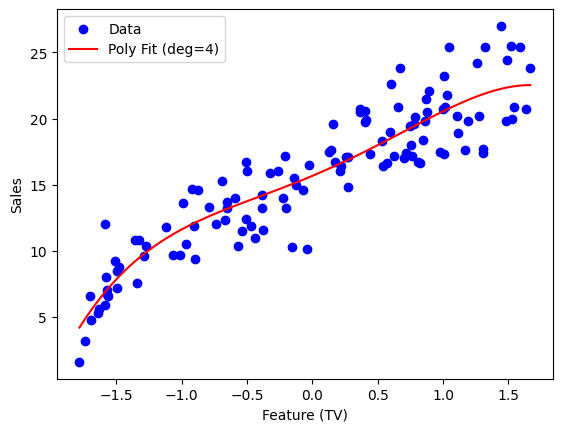

In [ ]:

X_train_single = X_train_scaled[:, [0]]
X_val_single = X_val_scaled[:, [0]]
X_test_single = X_test_scaled[:, [0]]

degree = 4
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_single)
X_val_poly = poly.transform(X_val_single)
X_test_poly = poly.transform(X_test_single)

# Add bias
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0], 1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0], 1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0], 1))])

# Train OLS
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# For curve plotting
X_plot = np.linspace(X_train_single.min(), X_train_single.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
X_plot_poly_bias = np.hstack([X_plot_poly, np.ones((X_plot_poly.shape[0], 1))])
y_plot = X_plot_poly_bias @ w_poly

# Plot
plt.scatter(X_train_single, y_train, color='blue', label='Data')
plt.plot(X_plot, y_plot, color='red', label=f'Poly Fit (deg={degree})')
plt.xlabel('Feature (TV)')
plt.ylabel('Sales')
plt.legend()
plt.show()


In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# Choose polynomial degree
degree = 5

# Create polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)
X_test_poly = poly.transform(X_test_scaled)

# Add bias column
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0],1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0],1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0],1))])

# Train OLS on polynomial features
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# Predictions
y_val_pred_poly = X_val_poly_bias @ w_poly
y_test_pred_poly = X_test_poly_bias @ w_poly

# Evaluation
val_mse_poly = mean_squared_error(y_val, y_val_pred_poly)
val_r2_poly = r2_score(y_val, y_val_pred_poly)
test_mse_poly = mean_squared_error(y_test, y_test_pred_poly)
test_r2_poly = r2_score(y_test, y_test_pred_poly)

print(f"Polynomial Regression (degree={degree}) Validation MSE: {val_mse_poly:.2f}, R2: {val_r2_poly:.2f}")
print(f"Polynomial Regression (degree={degree}) Test MSE: {test_mse_poly:.2f}, R2: {test_r2_poly:.2f}")


Polynomial Regression (degree=5) Validation MSE: 4.91, R2: 0.74
Polynomial Regression (degree=5) Test MSE: 84.25, R2: -1.73


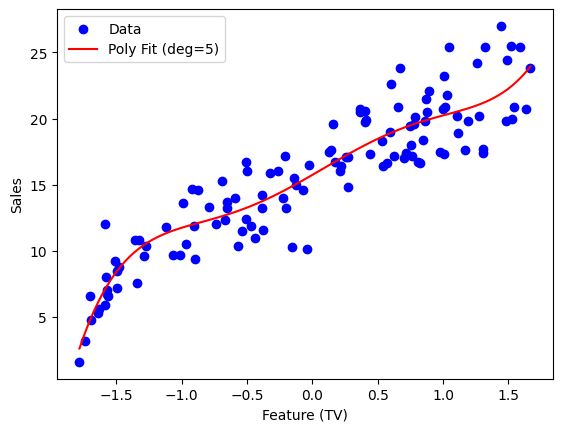

In [ ]:

X_train_single = X_train_scaled[:, [0]]
X_val_single = X_val_scaled[:, [0]]
X_test_single = X_test_scaled[:, [0]]

degree = 5
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_single)
X_val_poly = poly.transform(X_val_single)
X_test_poly = poly.transform(X_test_single)

# Add bias
X_train_poly_bias = np.hstack([X_train_poly, np.ones((X_train_poly.shape[0], 1))])
X_val_poly_bias = np.hstack([X_val_poly, np.ones((X_val_poly.shape[0], 1))])
X_test_poly_bias = np.hstack([X_test_poly, np.ones((X_test_poly.shape[0], 1))])

# Train OLS
w_poly = closed_form_ols(X_train_poly_bias, y_train)

# For curve plotting
X_plot = np.linspace(X_train_single.min(), X_train_single.max(), 100).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)
X_plot_poly_bias = np.hstack([X_plot_poly, np.ones((X_plot_poly.shape[0], 1))])
y_plot = X_plot_poly_bias @ w_poly

# Plot
plt.scatter(X_train_single, y_train, color='blue', label='Data')
plt.plot(X_plot, y_plot, color='red', label=f'Poly Fit (deg={degree})')
plt.xlabel('Feature (TV)')
plt.ylabel('Sales')
plt.legend()
plt.show()


Doing Lasso Regularization with alpha 0.01,0.1,1,10

In [ ]:
from sklearn.linear_model import Ridge, Lasso


X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L1 Regularization (Lasso) ----
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_lin, y_train)

y_val_pred_lasso = lasso.predict(X_val_lin)
y_test_pred_lasso = lasso.predict(X_test_lin)

print("\nLasso Regression (L1)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_lasso))
print("Validation R2:", r2_score(y_val, y_val_pred_lasso))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_lasso))
print("Test R2:", r2_score(y_test, y_test_pred_lasso))



Lasso Regression (L1)
Validation MSE: 3.0803802844346193
Validation R2: 0.8379693285961194
Test MSE: 2.853953128057872
Test R2: 0.907642345157361


In [ ]:
from sklearn.linear_model import Ridge, Lasso

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L1 Regularization (Lasso) ----
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_lin, y_train)

y_val_pred_lasso = lasso.predict(X_val_lin)
y_test_pred_lasso = lasso.predict(X_test_lin)

print("\nLasso Regression (L1)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_lasso))
print("Validation R2:", r2_score(y_val, y_val_pred_lasso))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_lasso))
print("Test R2:", r2_score(y_test, y_test_pred_lasso))



Lasso Regression (L1)
Validation MSE: 2.9580197005757305
Validation R2: 0.8444056013044631
Test MSE: 2.8343927733112535
Test R2: 0.9082753438126392


In [ ]:
from sklearn.linear_model import Ridge, Lasso

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L1 Regularization (Lasso) ----
lasso = Lasso(alpha=1, max_iter=10000)
lasso.fit(X_train_lin, y_train)

y_val_pred_lasso = lasso.predict(X_val_lin)
y_test_pred_lasso = lasso.predict(X_test_lin)

print("\nLasso Regression (L1)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_lasso))
print("Validation R2:", r2_score(y_val, y_val_pred_lasso))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_lasso))
print("Test R2:", r2_score(y_test, y_test_pred_lasso))



Lasso Regression (L1)
Validation MSE: 3.2829427305840886
Validation R2: 0.8273143684547825
Test MSE: 4.97182316656352
Test R2: 0.8391053015406079


In [ ]:
from sklearn.linear_model import Ridge, Lasso

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L1 Regularization (Lasso) ----
lasso = Lasso(alpha=10, max_iter=10000)
lasso.fit(X_train_lin, y_train)

y_val_pred_lasso = lasso.predict(X_val_lin)
y_test_pred_lasso = lasso.predict(X_test_lin)

print("\nLasso Regression (L1)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_lasso))
print("Validation R2:", r2_score(y_val, y_val_pred_lasso))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_lasso))
print("Test R2:", r2_score(y_test, y_test_pred_lasso))



Lasso Regression (L1)
Validation MSE: 19.992844444444444
Validation R2: -0.05164093698945882
Test MSE: 32.45943611111111
Test R2: -0.05042979412095727


Ridge Regression with alpha values 0.01,0.1,1,10

In [ ]:

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L2 Regularization (Ridge) ----
ridge = Ridge(alpha=0.01)
ridge.fit(X_train_lin, y_train)

y_val_pred_ridge = ridge.predict(X_val_lin)
y_test_pred_ridge = ridge.predict(X_test_lin)

print("Ridge Regression (L2)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_ridge))
print("Validation R2:", r2_score(y_val, y_val_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_ridge))
print("Test R2:", r2_score(y_test, y_test_pred_ridge))


Ridge Regression (L2)
Validation MSE: 3.0962112190779445
Validation R2: 0.8371366077200085
Test MSE: 2.8594958700726196
Test R2: 0.907462974778483


In [ ]:

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L2 Regularization (Ridge) ----
ridge = Ridge(alpha=0.1)
ridge.fit(X_train_lin, y_train)

y_val_pred_ridge = ridge.predict(X_val_lin)
y_test_pred_ridge = ridge.predict(X_test_lin)

print("Ridge Regression (L2)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_ridge))
print("Validation R2:", r2_score(y_val, y_val_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_ridge))
print("Test R2:", r2_score(y_test, y_test_pred_ridge))


Ridge Regression (L2)
Validation MSE: 3.092667017010051
Validation R2: 0.8373230358190175
Test MSE: 2.859211889178277
Test R2: 0.9074721647715364


In [ ]:

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L2 Regularization (Ridge) ----
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_lin, y_train)

y_val_pred_ridge = ridge.predict(X_val_lin)
y_test_pred_ridge = ridge.predict(X_test_lin)

print("Ridge Regression (L2)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_ridge))
print("Validation R2:", r2_score(y_val, y_val_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_ridge))
print("Test R2:", r2_score(y_test, y_test_pred_ridge))


Ridge Regression (L2)
Validation MSE: 3.0586886398351583
Validation R2: 0.8391103278928831
Test MSE: 2.858008749535445
Test R2: 0.9075110999435151


In [ ]:

X_train_lin = X_train_scaled
X_val_lin = X_val_scaled
X_test_lin = X_test_scaled

# ---- L2 Regularization (Ridge) ----
ridge = Ridge(alpha=10)
ridge.fit(X_train_lin, y_train)

y_val_pred_ridge = ridge.predict(X_val_lin)
y_test_pred_ridge = ridge.predict(X_test_lin)

print("Ridge Regression (L2)")
print("Validation MSE:", mean_squared_error(y_val, y_val_pred_ridge))
print("Validation R2:", r2_score(y_val, y_val_pred_ridge))
print("Test MSE:", mean_squared_error(y_test, y_test_pred_ridge))
print("Test R2:", r2_score(y_test, y_test_pred_ridge))


Ridge Regression (L2)
Validation MSE: 2.846190403046707
Validation R2: 0.850287919228913
Test MSE: 2.9864419941734184
Test R2: 0.903354832217189


In [ ]:
import numpy as np

# Mean Squared Error + optional L2 regularization
def compute_loss(X, y, w, alpha=0.0):
    n = X.shape[0]
    y_pred = X @ w
    mse = (1/(2*n)) * np.sum((y - y_pred)**2)
    reg = (alpha/2) * np.sum(w[:-1]**2)  # exclude bias from regularization
    return mse + reg

# Gradient of loss for Ridge (L2)
def compute_gradient(X, y, w, alpha=0.0):
    n = X.shape[0]
    y_pred = X @ w
    grad = -(1/n) * X.T @ (y - y_pred)
    grad[:-1] += alpha * w[:-1]  # exclude bias
    return grad


In [ ]:
def gradient_descent(X, y, lr=0.01, alpha=0.0, epochs=1000, batch_size=None):
    n_samples, n_features = X.shape
    w = np.zeros(n_features)  # initialize weights
    losses = []

    for epoch in range(epochs):
        if batch_size is None:
            # Full-batch
            X_batch, y_batch = X, y
        else:
            # Mini-batch / SGD
            indices = np.random.permutation(n_samples)
            X, y = X[indices], y[indices]
            X_batch = X[:batch_size]
            y_batch = y[:batch_size]

        grad = compute_gradient(X_batch, y_batch, w, alpha)
        w = w - lr * grad
        loss = compute_loss(X, y, w, alpha)
        losses.append(loss)

    return w, losses


In [ ]:
# Add bias column
X_train_bias = np.hstack([X_train_scaled, np.ones((X_train_scaled.shape[0],1))])
X_val_bias = np.hstack([X_val_scaled, np.ones((X_val_scaled.shape[0],1))])
X_test_bias = np.hstack([X_test_scaled, np.ones((X_test_scaled.shape[0],1))])

# Hyperparameters
lr = 0.01
epochs = 500

# Full-batch
w_fb, losses_fb = gradient_descent(X_train_bias, y_train, lr=lr, alpha=0.0, epochs=epochs, batch_size=None)

# Mini-batch (batch_size=16)
w_mb, losses_mb = gradient_descent(X_train_bias, y_train, lr=lr, alpha=0.0, epochs=epochs, batch_size=16)

# Stochastic (batch_size=1)
w_sgd, losses_sgd = gradient_descent(X_train_bias, y_train, lr=lr, alpha=0.0, epochs=epochs, batch_size=1)



Plotting the convergence of different gradient descent methods

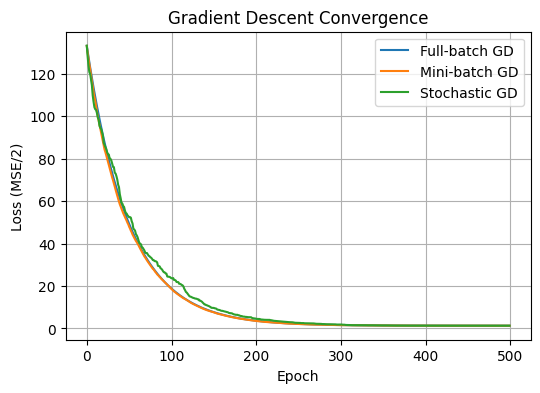

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(losses_fb, label="Full-batch GD")
plt.plot(losses_mb, label="Mini-batch GD")
plt.plot(losses_sgd, label="Stochastic GD")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE/2)")
plt.title("Gradient Descent Convergence")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_test_fb = X_test_bias @ w_fb
y_test_mb = X_test_bias @ w_mb
y_test_sgd = X_test_bias @ w_sgd

print("Full-batch GD Test MSE:", mean_squared_error(y_test, y_test_fb), "R2:", r2_score(y_test, y_test_fb))
print("Mini-batch GD Test MSE:", mean_squared_error(y_test, y_test_mb), "R2:", r2_score(y_test, y_test_mb))
print("Stochastic GD Test MSE:", mean_squared_error(y_test, y_test_sgd), "R2:", r2_score(y_test, y_test_sgd))


Full-batch GD Test MSE: 2.808687874117434 R2: 0.9091071879603821
Mini-batch GD Test MSE: 2.812524516495796 R2: 0.9089830291965076
Stochastic GD Test MSE: 2.9037360978767746 R2: 0.9060313031614805
